In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn
!pip install -q tensorflow keras
!pip install -q pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 16.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/LMD2023_Project/archive.zip"

In [ ]:
import zipfile

extract_path = "/content/lmd2023"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [ ]:
import os

base_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".zip"):
            print("ZIP FILE:", os.path.join(root, f))

ZIP FILE: /content/drive/MyDrive/DL_HW2_ImageCaptioning/dataset/Flickr8k_Dataset.zip
ZIP FILE: /content/drive/MyDrive/DL_HW2_ImageCaptioning/dataset/Flickr8k_text.zip
ZIP FILE: /content/drive/MyDrive/LMD2023_Project/archive.zip


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/LMD2023_Project/archive.zip"
extract_path = "/content/LMD2023"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

Extraction Done!


In [ ]:
import os

base_path = "/content/LMD2023"

for root, dirs, files in os.walk(base_path):
    print("📁", root)

    for f in files[:5]:
        print("   -", f)

    print("--------------")

📁 /content/LMD2023
--------------
📁 /content/LMD2023/LMD-2023 1.75M Elements Checked
   - LMD-2023 1.75M ElementsChecked.csv
--------------
📁 /content/LMD2023/LMD-2023 1.75M Elements Checked/Preprocessed LMD-2023
   - LMD-2023 1.75M Elements Labelled+Preprocessed.csv
--------------
📁 /content/LMD2023/LMD-2023 1.75M Elements Checked/Labelled LMD-2023
   - LMD-2023 1.75M Elements Labelled checked.csv
--------------
📁 /content/LMD2023/LMD-2023 1.75M Elements Checked/Labelled LMD-2023/Labelled Subsets
   - LMD-2023 1.75M Elements - EoRS checked.csv
   - LMD-2023 1.75M Elements - EoHTchecked.csv
   - LMD-2023 1.75M Elements - Normal checked.csv
--------------


In [ ]:
import pandas as pd

path = "/content/LMD2023/LMD-2023 1.75M Elements Checked/Preprocessed LMD-2023/LMD-2023 1.75M Elements Labelled+Preprocessed.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(1723308, 83)


,SystemTime,EventRecordID,Execution_ProcessID,ProcessId,Unnamed: 0.2,SystemTime_day,SystemTime_hour,SystemTime_minute,Label,EventID_0.0,...,SystemTime_week_47,SystemTime_week_48,SystemTime_week_49,SystemTime_day_of_week_0,SystemTime_day_of_week_1,SystemTime_day_of_week_2,SystemTime_day_of_week_3,SystemTime_day_of_week_4,SystemTime_day_of_week_5,SystemTime_day_of_week_6
0,2022-10-10 10:35:33.000000,0.000011,0.0,0.567183,0,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
1,2022-10-10 10:35:49.417052,0.000011,0.0,0.567183,1,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2022-10-10 10:35:50.922113,0.000011,0.0,0.000156,2,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
3,2022-10-10 10:36:07.534514,0.000011,0.0,0.000156,3,0.269231,0.434783,0.610169,0,0,...,0,0,0,1,0,0,0,0,0,0
4,2022-10-10 10:35:42.454330,0.000049,0.0,0.000000,4,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
import pandas as pd

df = df

X = df.drop(columns=['Label'])
y = df['Label']

print(X.shape, y.shape)

(1723308, 82) (1723308,)


In [ ]:
X_clean = X.copy()

X_clean = X_clean.drop(columns=['SystemTime'])

print(X_clean.shape)

(1723308, 81)


In [ ]:
print(X_clean.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)

print(X_scaled.shape)

(1723308, 81)


In [ ]:
import tensorflow as tf
from tensorflow import keras

input_dim = X_scaled.shape[1]

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),   # bottleneck
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(input_dim, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 81)             │         5,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,777 (61.63 KB)

 Trainable params: 15,777 (61.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_scaled,
    X_scaled,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0047 - val_loss: 0.0569
Epoch 2/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0020 - val_loss: 0.0594
Epoch 3/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0019 - val_loss: 0.0614
Epoch 4/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0017 - val_loss: 0.0424
Epoch 5/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0014 - val_loss: 0.0539
Epoch 6/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0013 - val_loss: 0.0474
Epoch 7/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0013 - val_loss: 0.0469
Epoch 8/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0012 - val_loss: 0.0483
Epoch 9/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0010 - val_loss: 0.0496
Epoch 10/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 6.6987e-04 - val_loss: 0.0497


In [ ]:
import numpy as np

X_pred = model.predict(X_scaled)

mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

print(mse.shape)
print(mse[:10])

53854/53854 ━━━━━━━━━━━━━━━━━━━━ 95s 2ms/step
(1723308,)
[0.03816481 0.00813306 0.01254599 0.00178717 0.01790145 0.01788877
 0.00170256 0.00170393 0.01562007 0.01562007]


In [ ]:
import numpy as np

threshold = np.percentile(mse, 95)
print("Threshold:", threshold)

Threshold: 0.09449968932698222


In [ ]:
y_pred = (mse > threshold).astype(int)

print("Predicted attacks:", np.sum(y_pred))

Predicted attacks: 86166


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[1590353       8       0]
 [  46706   59557       0]
 [     83   26601       0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99   1590361
           1       0.69      0.56      0.62    106263
           2       0.00      0.00      0.00     26684

    accuracy                           0.96   1723308
   macro avg       0.55      0.52      0.53   1723308
weighted avg       0.94      0.96      0.95   1723308



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso = IsolationForest(contamination=0.05, random_state=42)

y_iso = iso.fit_predict(X_scaled)

y_iso = np.where(y_iso == -1, 1, 0)

print(confusion_matrix(y, y_iso))
print(classification_report(y, y_iso))

[[1560312   30049       0]
 [  75535   30728       0]
 [   1324   25360       0]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97   1590361
           1       0.36      0.29      0.32    106263
           2       0.00      0.00      0.00     26684

    accuracy                           0.92   1723308
   macro avg       0.44      0.42      0.43   1723308
weighted avg       0.90      0.92      0.91   1723308



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_binary = (y != 0).astype(int)

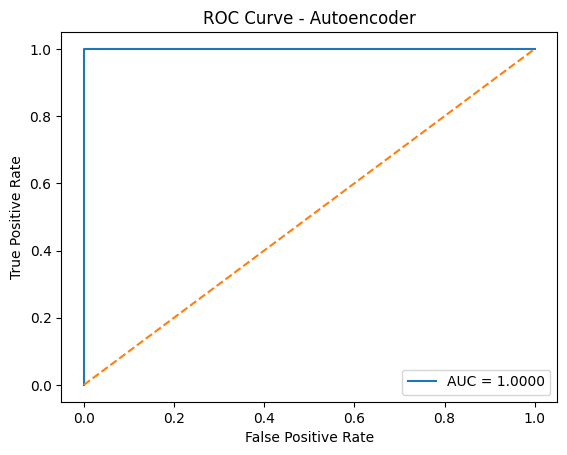

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_binary, mse)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder")
plt.legend()
plt.show()

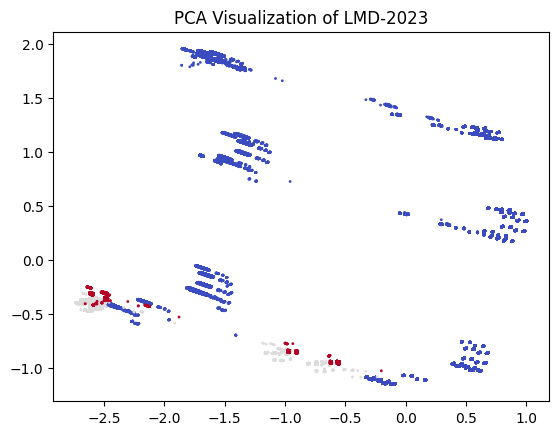

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', s=1)
plt.title("PCA Visualization of LMD-2023")
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ---------- Autoencoder (binary) ----------
y_auto = (mse > np.percentile(mse, 95)).astype(int)

# ---------- Isolation Forest ----------
iso = IsolationForest(contamination=0.05, random_state=42)
y_iso = iso.fit_predict(X_scaled)
y_iso = np.where(y_iso == -1, 1, 0)

# ---------- ground truth binary ----------
y_true = (y != 0).astype(int)

# ---------- metrics function ----------
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

auto_metrics = get_metrics(y_true, y_auto)
iso_metrics = get_metrics(y_true, y_iso)

# ---------- print ----------
print("Autoencoder:", auto_metrics)
print("Isolation Forest:", iso_metrics)

Autoencoder: {'Accuracy': 0.9728446685096338, 'Precision': 0.999907155954785, 'Recall': 0.6480627618524675, 'F1': 0.7864252691533592}
Isolation Forest: {'Accuracy': 0.93796349810945, 'Precision': 0.6511487514076413, 'Recall': 0.4218824042663618, 'F1': 0.5120227857807964}


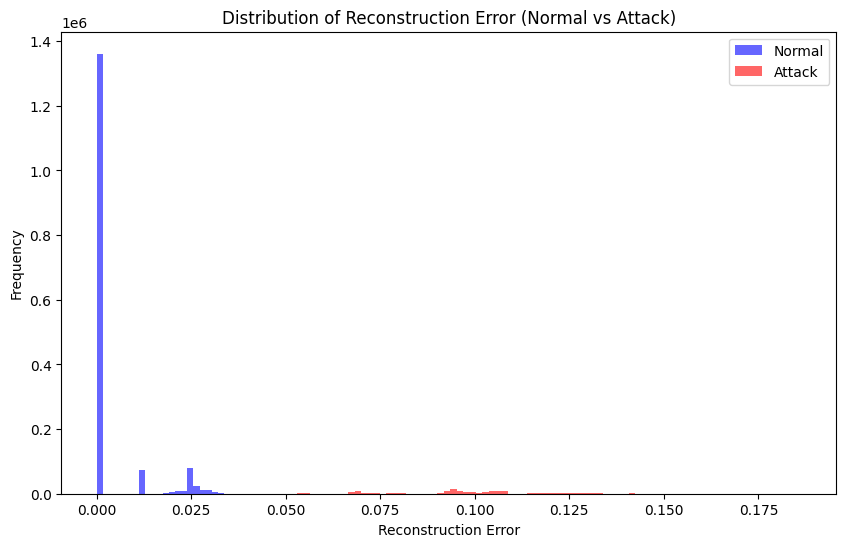

In [ ]:
import matplotlib.pyplot as plt

normal_error = mse[y_true == 0]
attack_error = mse[y_true == 1]

plt.figure(figsize=(10,6))

plt.hist(normal_error, bins=100, alpha=0.6, label="Normal", color="blue")
plt.hist(attack_error, bins=100, alpha=0.6, label="Attack", color="red")

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Error (Normal vs Attack)")
plt.legend()

plt.show()